# Setup

In [ ]:
cd /content/sample_data

/content/sample_data


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway, ttest_ind, chi2_contingency, pearsonr, levene
from numpy.linalg import lstsq
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

# ── Load ────────────────────────────────────────────────────────────────────
df = pd.read_csv('climate_change_dataset.csv')

numeric_cols = [
    'Avg Temperature (°C)', 'CO2 Emissions (Tons/Capita)',
    'Sea Level Rise (mm)', 'Rainfall (mm)', 'Population',
    'Renewable Energy (%)', 'Extreme Weather Events', 'Forest Area (%)'
]

print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Shape: 1,000 rows × 10 columns


,Year,Country,Avg Temperature (°C),CO2 Emissions (Tons/Capita),Sea Level Rise (mm),Rainfall (mm),Population,Renewable Energy (%),Extreme Weather Events,Forest Area (%)
0,2006,UK,8.9,9.3,3.1,1441,530911230,20.4,14,59.8
1,2019,USA,31.0,4.8,4.2,2407,107364344,49.2,8,31.0
2,2014,France,33.9,2.8,2.2,1241,441101758,33.3,9,35.5
3,2010,Argentina,5.9,1.8,3.2,1892,1069669579,23.7,7,17.7
4,2007,Germany,26.9,5.6,2.4,1743,124079175,12.5,4,17.4



# Task 1

### 1. Research Question Hypotheses

| Q | Research Question | H0 (Null Hypothesis) | H1 (Alternative Hypothesis) | Test Used |
|---|---|---|---|---|
| Q1 | Has the average temperature increased? | Average temperature has shown no upward trend over time | Average temperature has significantly increased over time | Linear Regression (OLS) |
| Q2 | Have extreme weather events increased? | The frequency of extreme weather events has not changed over time | Extreme weather events have significantly increased over time | Linear Regression (OLS) |
| Q3 | Which regions changed the most? | No country shows a significantly different temperature trend from others | At least one country shows a significantly different temperature trend | Per-country Linear Regression |
| Q4 | Has rainfall variability changed? | Rainfall variability is the same across time periods | Rainfall variability has significantly changed across time periods | Levene's Test |
| Q5 | Can historical data support future planning? | Historical climate variables have no predictive relationship with sea-level rise | Historical variables have a significant predictive relationship with future climate indicators | Correlation + Regression |
| Q6 | Does higher CO₂ correlate with rising temperatures? | There is no significant correlation between CO₂ emissions and average temperature | Higher CO₂ emissions are significantly associated with higher average temperatures | Pearson Correlation |
| Q7 | Has sea-level rise accelerated? | Sea-level rise rates are the same in early vs later years | Sea-level rise has significantly accelerated in more recent years | Linear Regression + T-Test |
| Q8 | Is there a relationship between temperature and sea-level rise? | There is no significant relationship between average temperature and sea-level rise | Higher average temperatures are significantly associated with higher sea-level rise | Pearson Correlation |
| Q9 | Which countries are the highest/lowest CO₂ contributors? | All countries contribute equally to CO₂ emissions on average | Countries differ significantly in their average CO₂ emissions | Descriptive + ANOVA |
| Q10 | Can CO₂, rainfall, and temperature predict sea-level rise? | CO₂ emissions, rainfall, and temperature together do not predict sea-level rise | The combination of CO₂, rainfall, and temperature significantly predicts sea-level rise | Multiple Linear Regression |

# Task 2

### Histograms

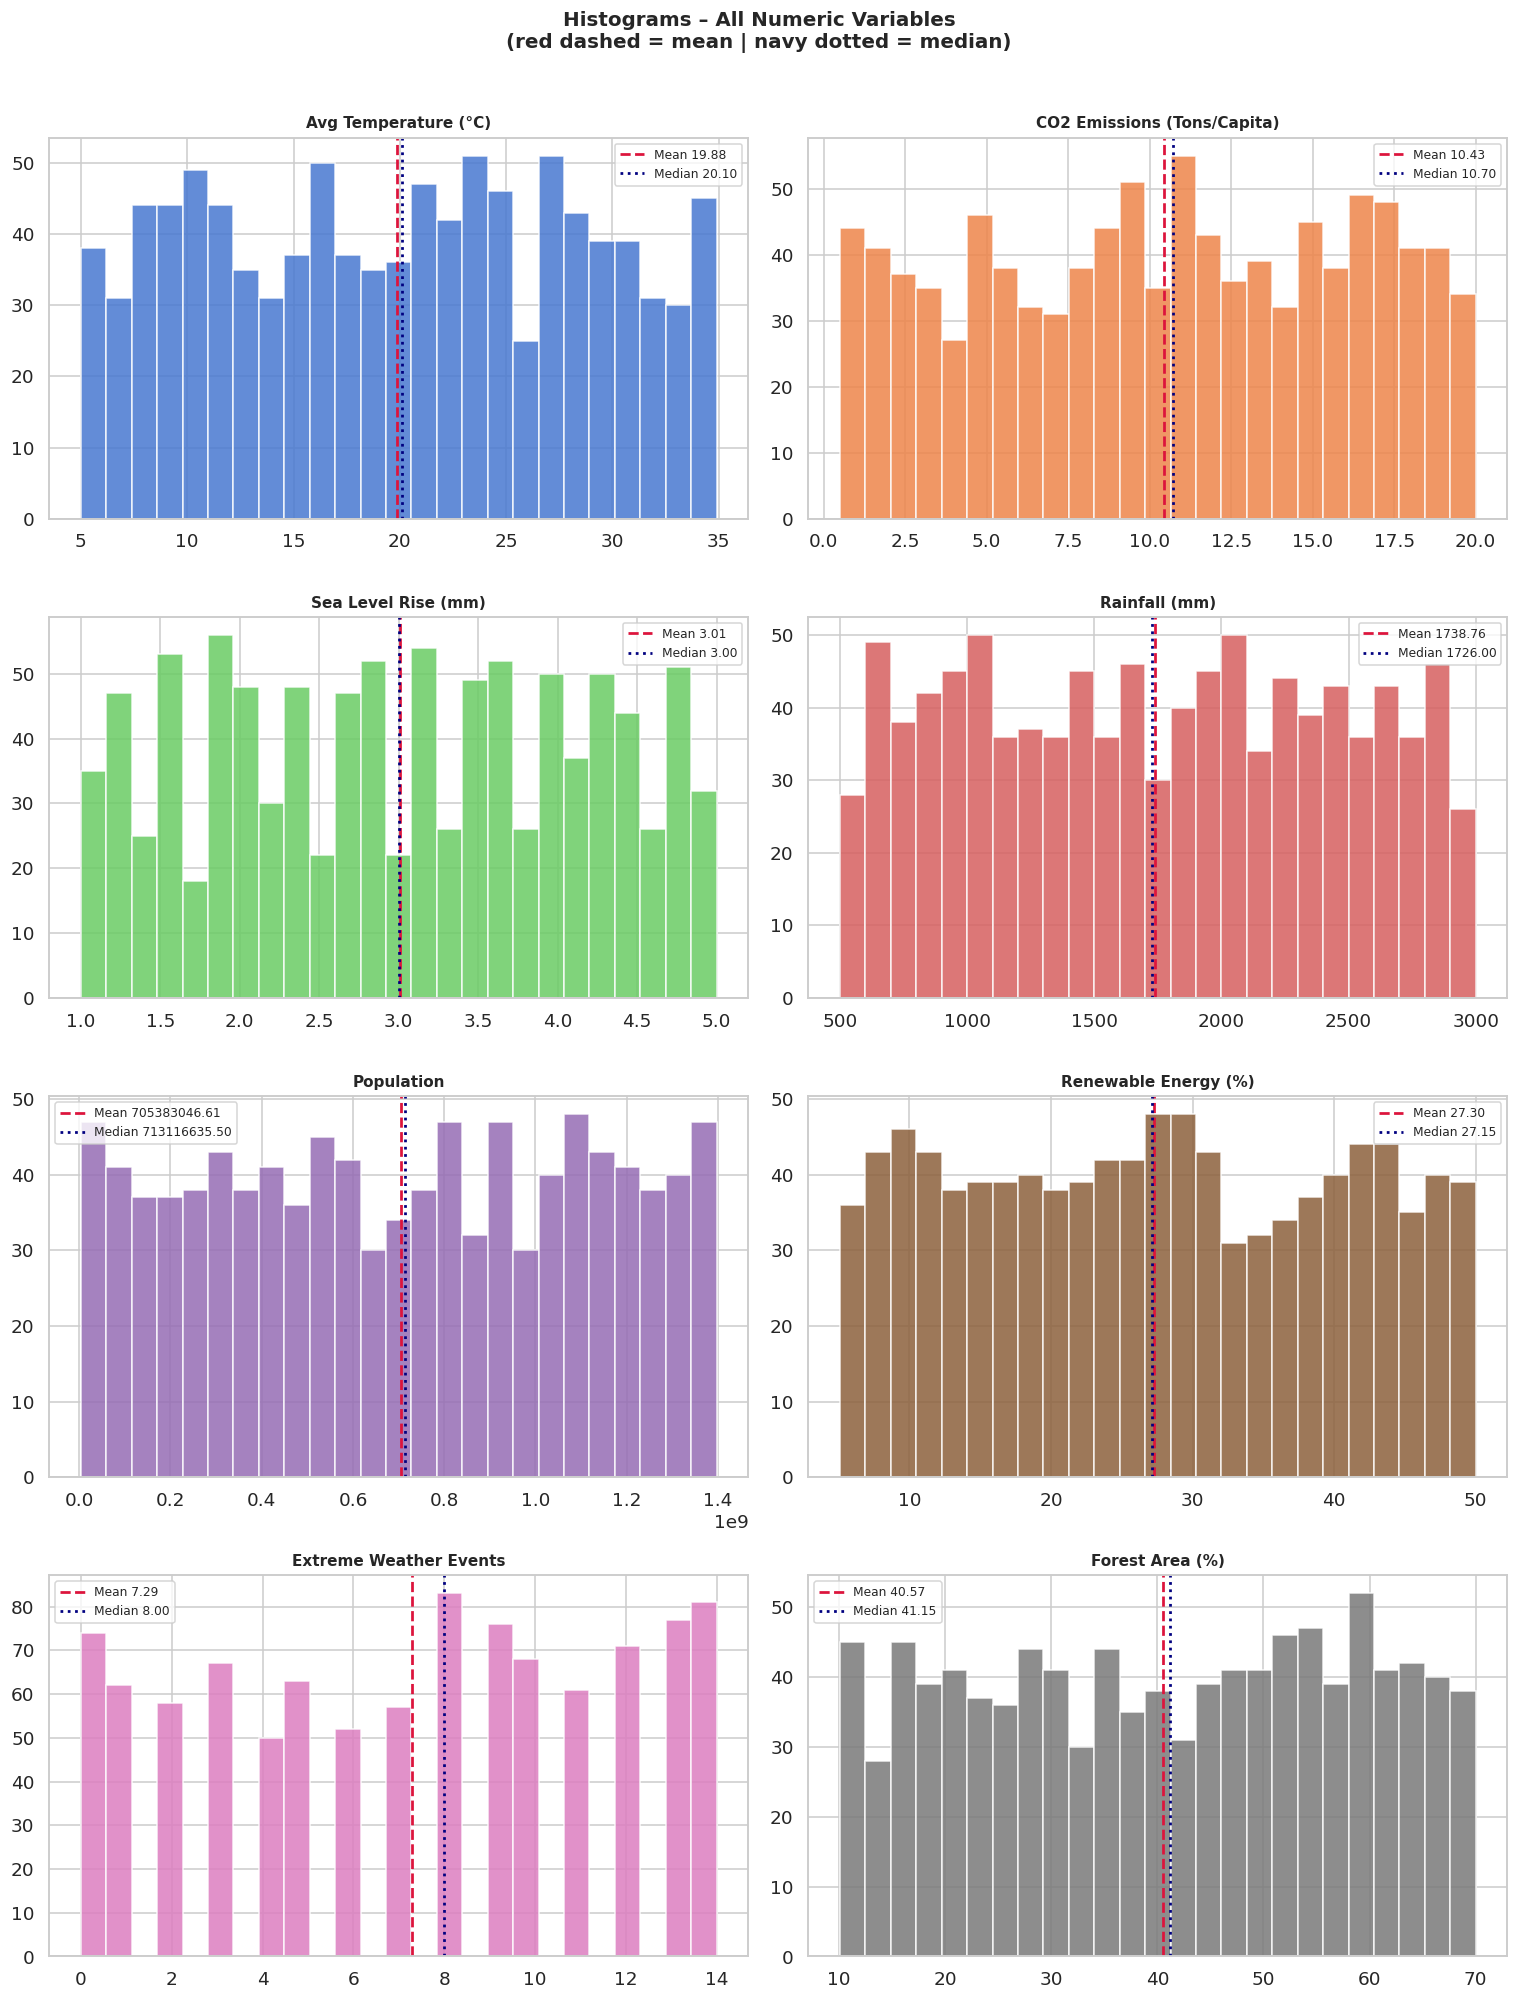

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()
colors = sns.color_palette('muted', len(numeric_cols))

for i, col in enumerate(numeric_cols):
    arr = np.array(df[col].dropna())
    ax  = axes[i]
    ax.hist(arr, bins=25, color=colors[i], edgecolor='white', alpha=0.85)
    ax.axvline(arr.mean(),   color='crimson', lw=1.8, ls='--', label=f'Mean {arr.mean():.2f}')
    ax.axvline(np.median(arr), color='navy', lw=1.8, ls=':',  label=f'Median {np.median(arr):.2f}')
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)

fig.suptitle('Histograms – All Numeric Variables\n(red dashed = mean | navy dotted = median)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Box Plots

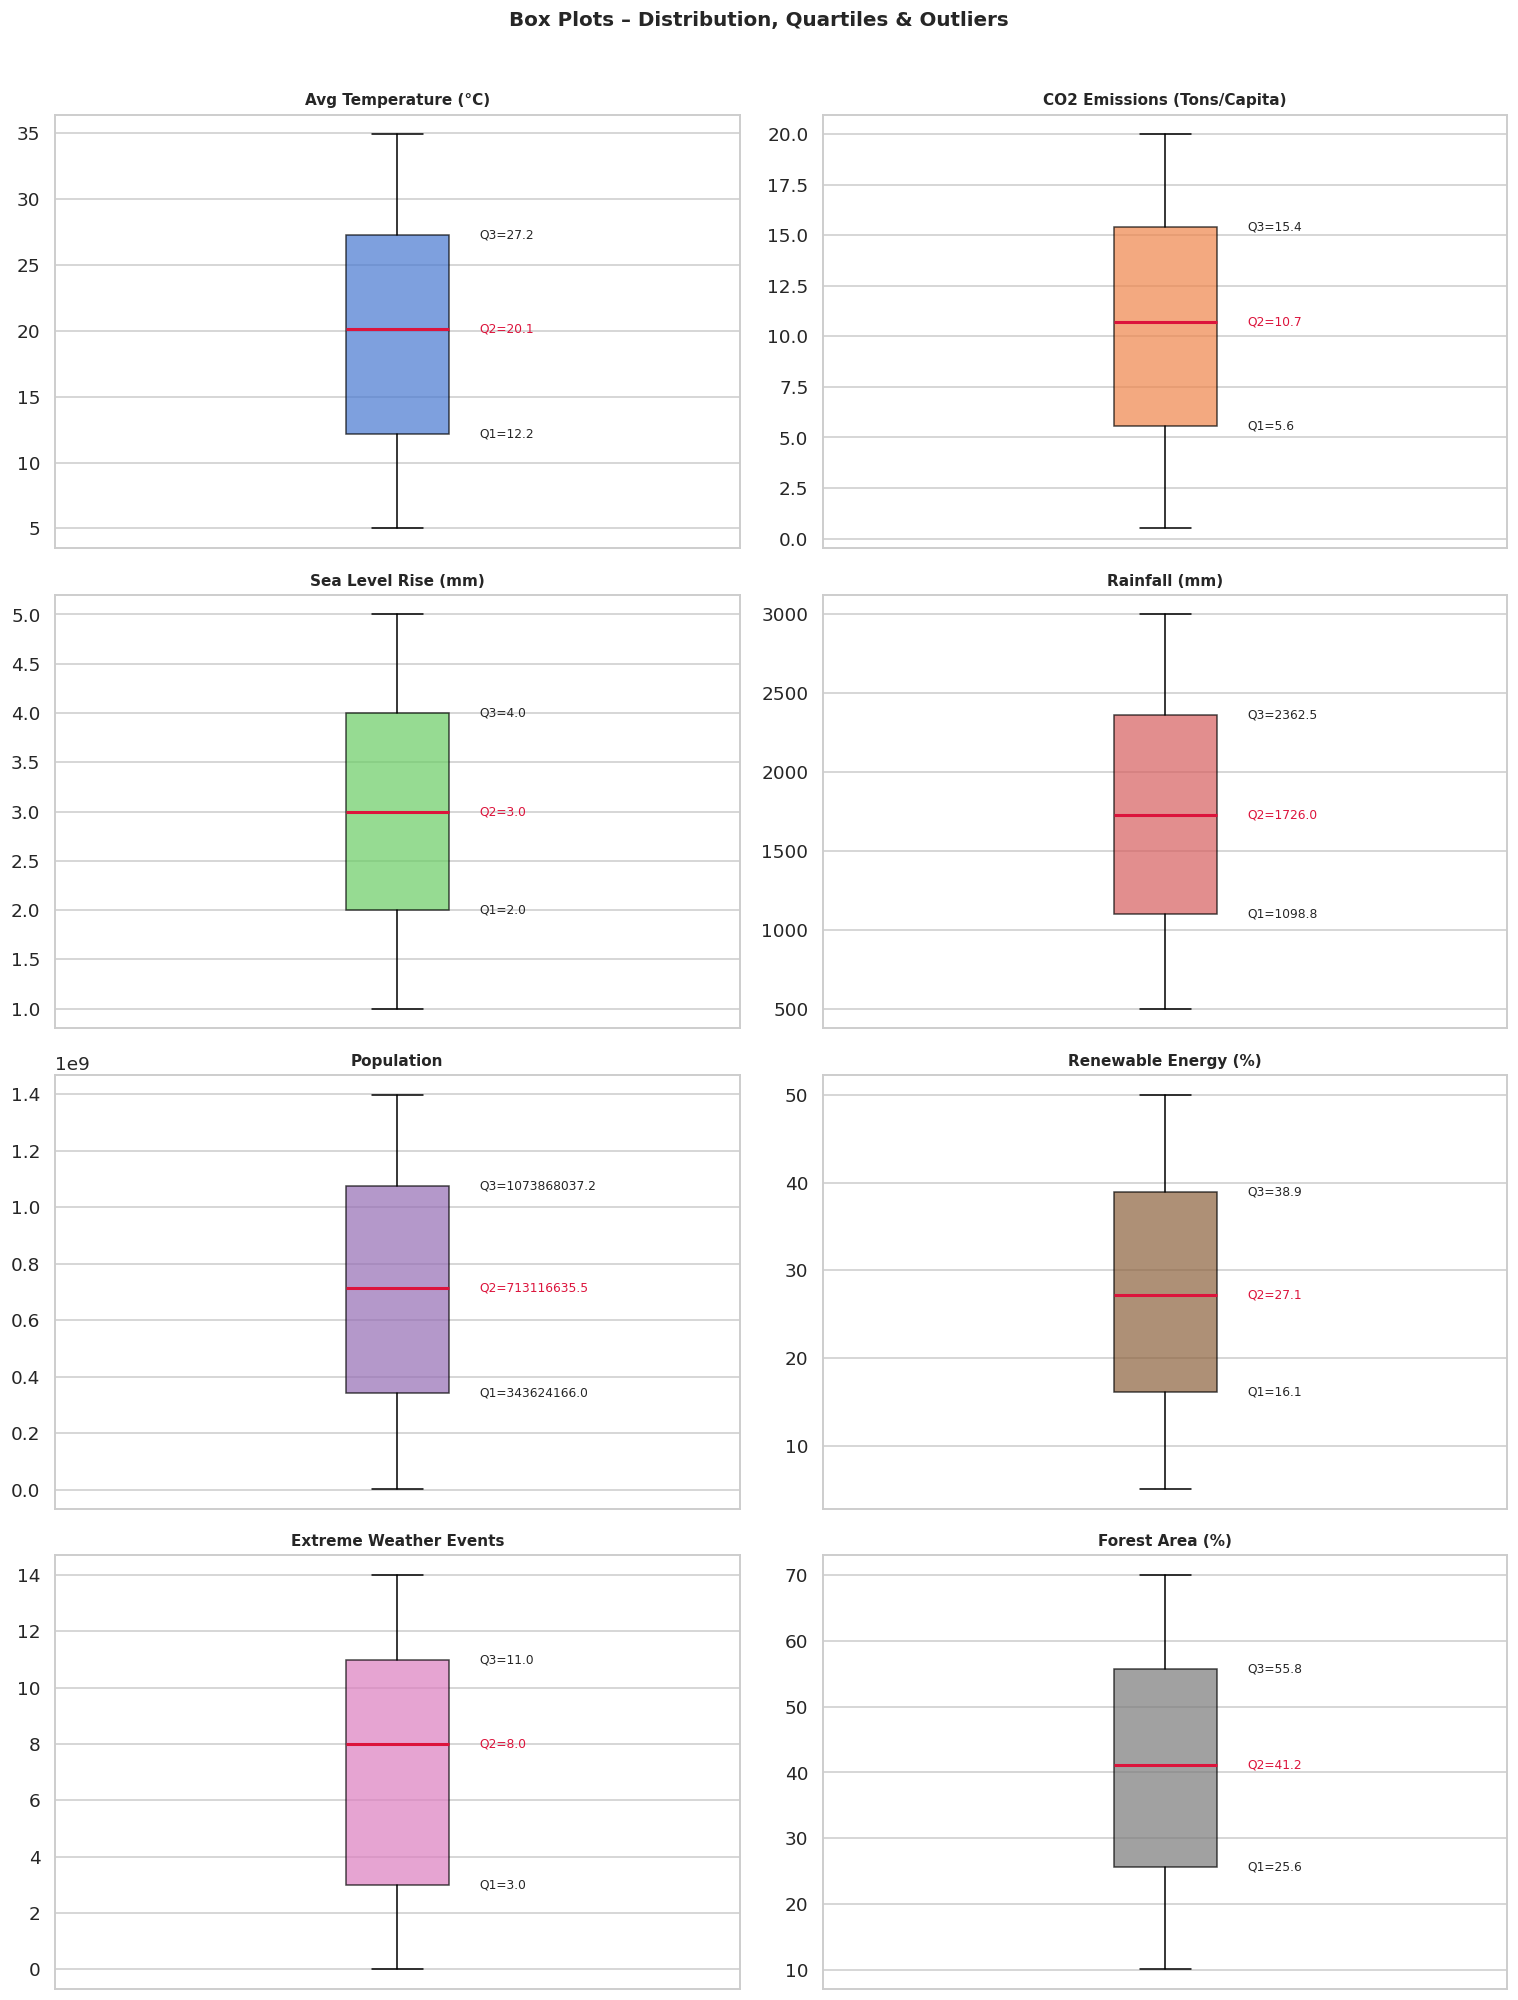

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    arr = np.array(df[col].dropna())
    ax  = axes[i]
    ax.boxplot(arr, patch_artist=True,
               boxprops=dict(facecolor=colors[i], alpha=0.7),
               medianprops=dict(color='crimson', lw=2),
               flierprops=dict(marker='o', markerfacecolor='red', markersize=3, alpha=0.4))
    q1, q2, q3 = np.percentile(arr, [25, 50, 75])
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xticks([])
    ax.text(1.12, q1, f'Q1={q1:.1f}', va='center', fontsize=8)
    ax.text(1.12, q2, f'Q2={q2:.1f}', va='center', fontsize=8, color='crimson')
    ax.text(1.12, q3, f'Q3={q3:.1f}', va='center', fontsize=8)

fig.suptitle('Box Plots – Distribution, Quartiles & Outliers',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Bar Charts

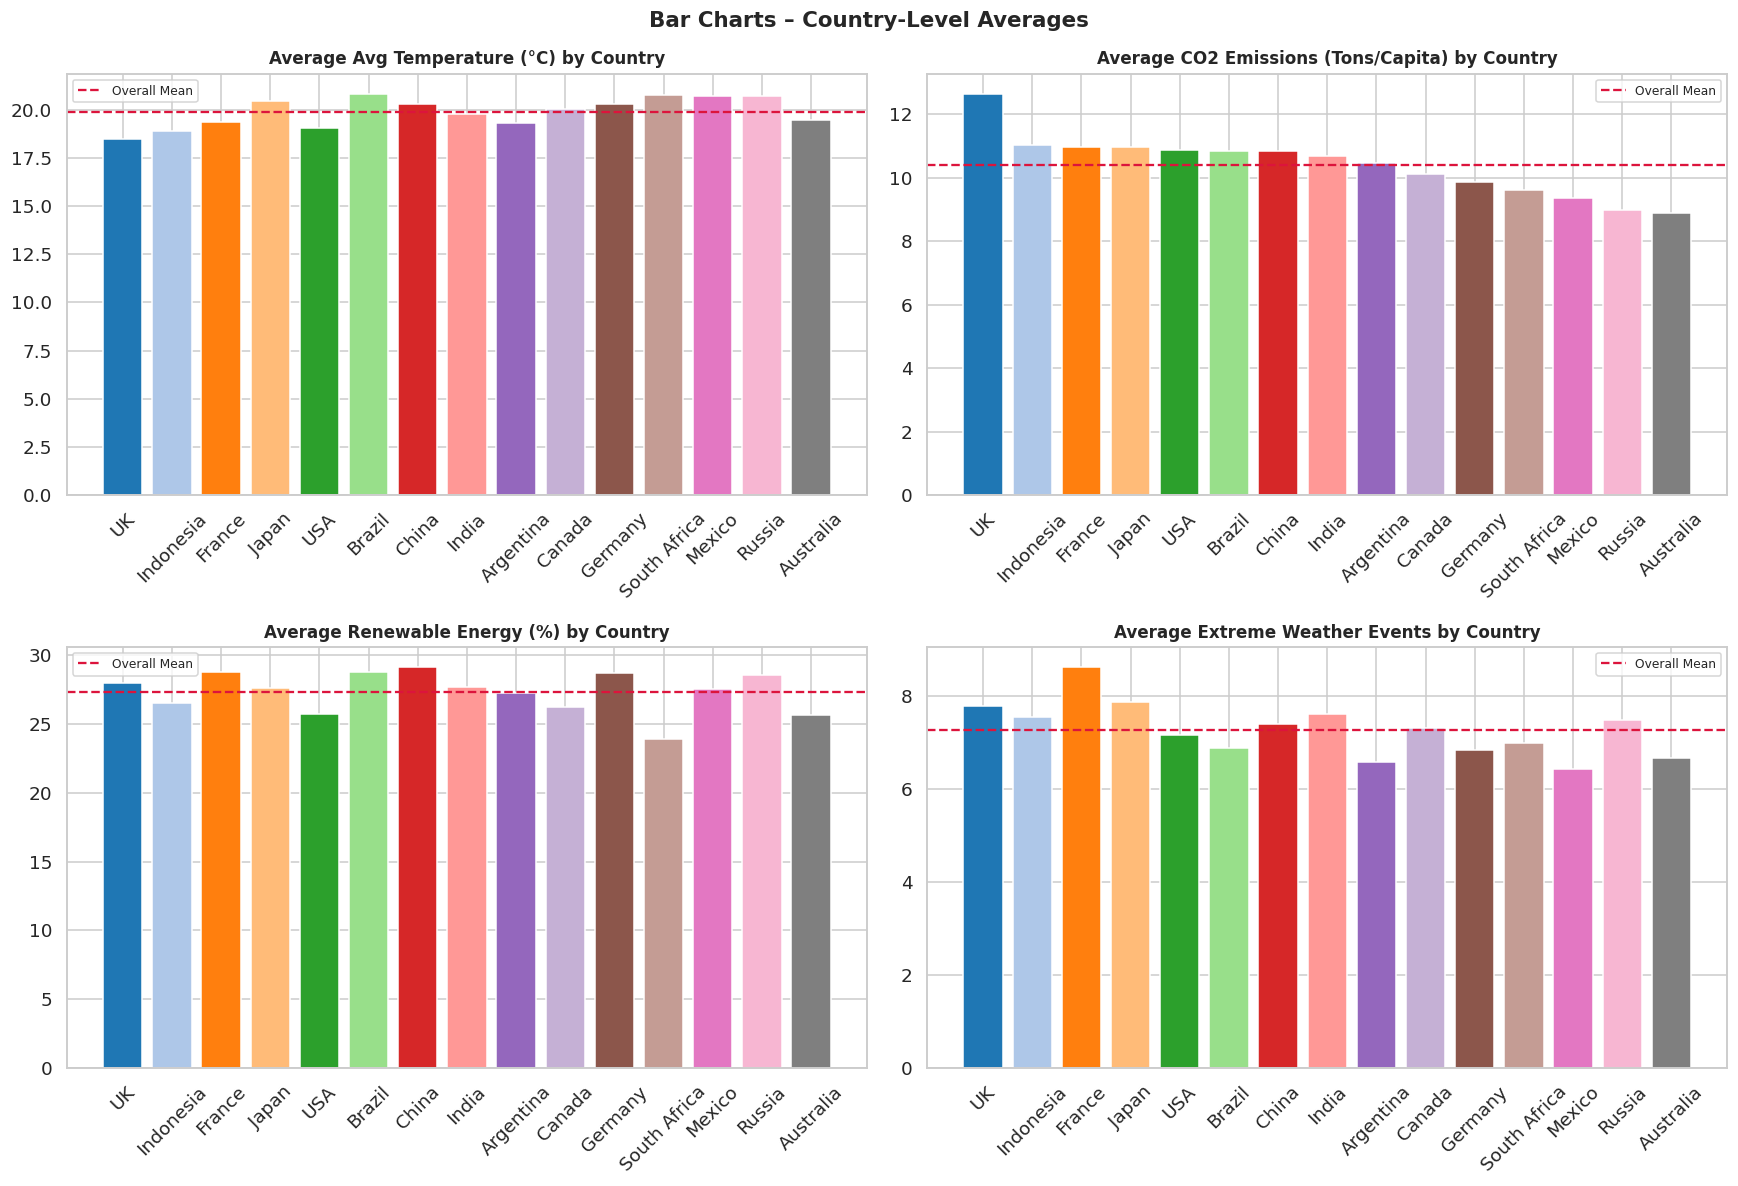

In [ ]:
bar_cols = [
    'Avg Temperature (°C)', 'CO2 Emissions (Tons/Capita)',
    'Renewable Energy (%)', 'Extreme Weather Events'
]
country_avg = df.groupby('Country')[bar_cols].mean().sort_values('CO2 Emissions (Tons/Capita)', ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()
bar_colors = sns.color_palette('tab20', len(country_avg))

for i, col in enumerate(bar_cols):
    ax = axes[i]
    bars = ax.bar(country_avg.index, country_avg[col], color=bar_colors, edgecolor='white')
    ax.set_title(f'Average {col} by Country', fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.axhline(country_avg[col].mean(), color='crimson', ls='--', lw=1.5, label='Overall Mean')
    ax.legend(fontsize=8)

fig.suptitle('Bar Charts – Country-Level Averages', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Scatter Plots

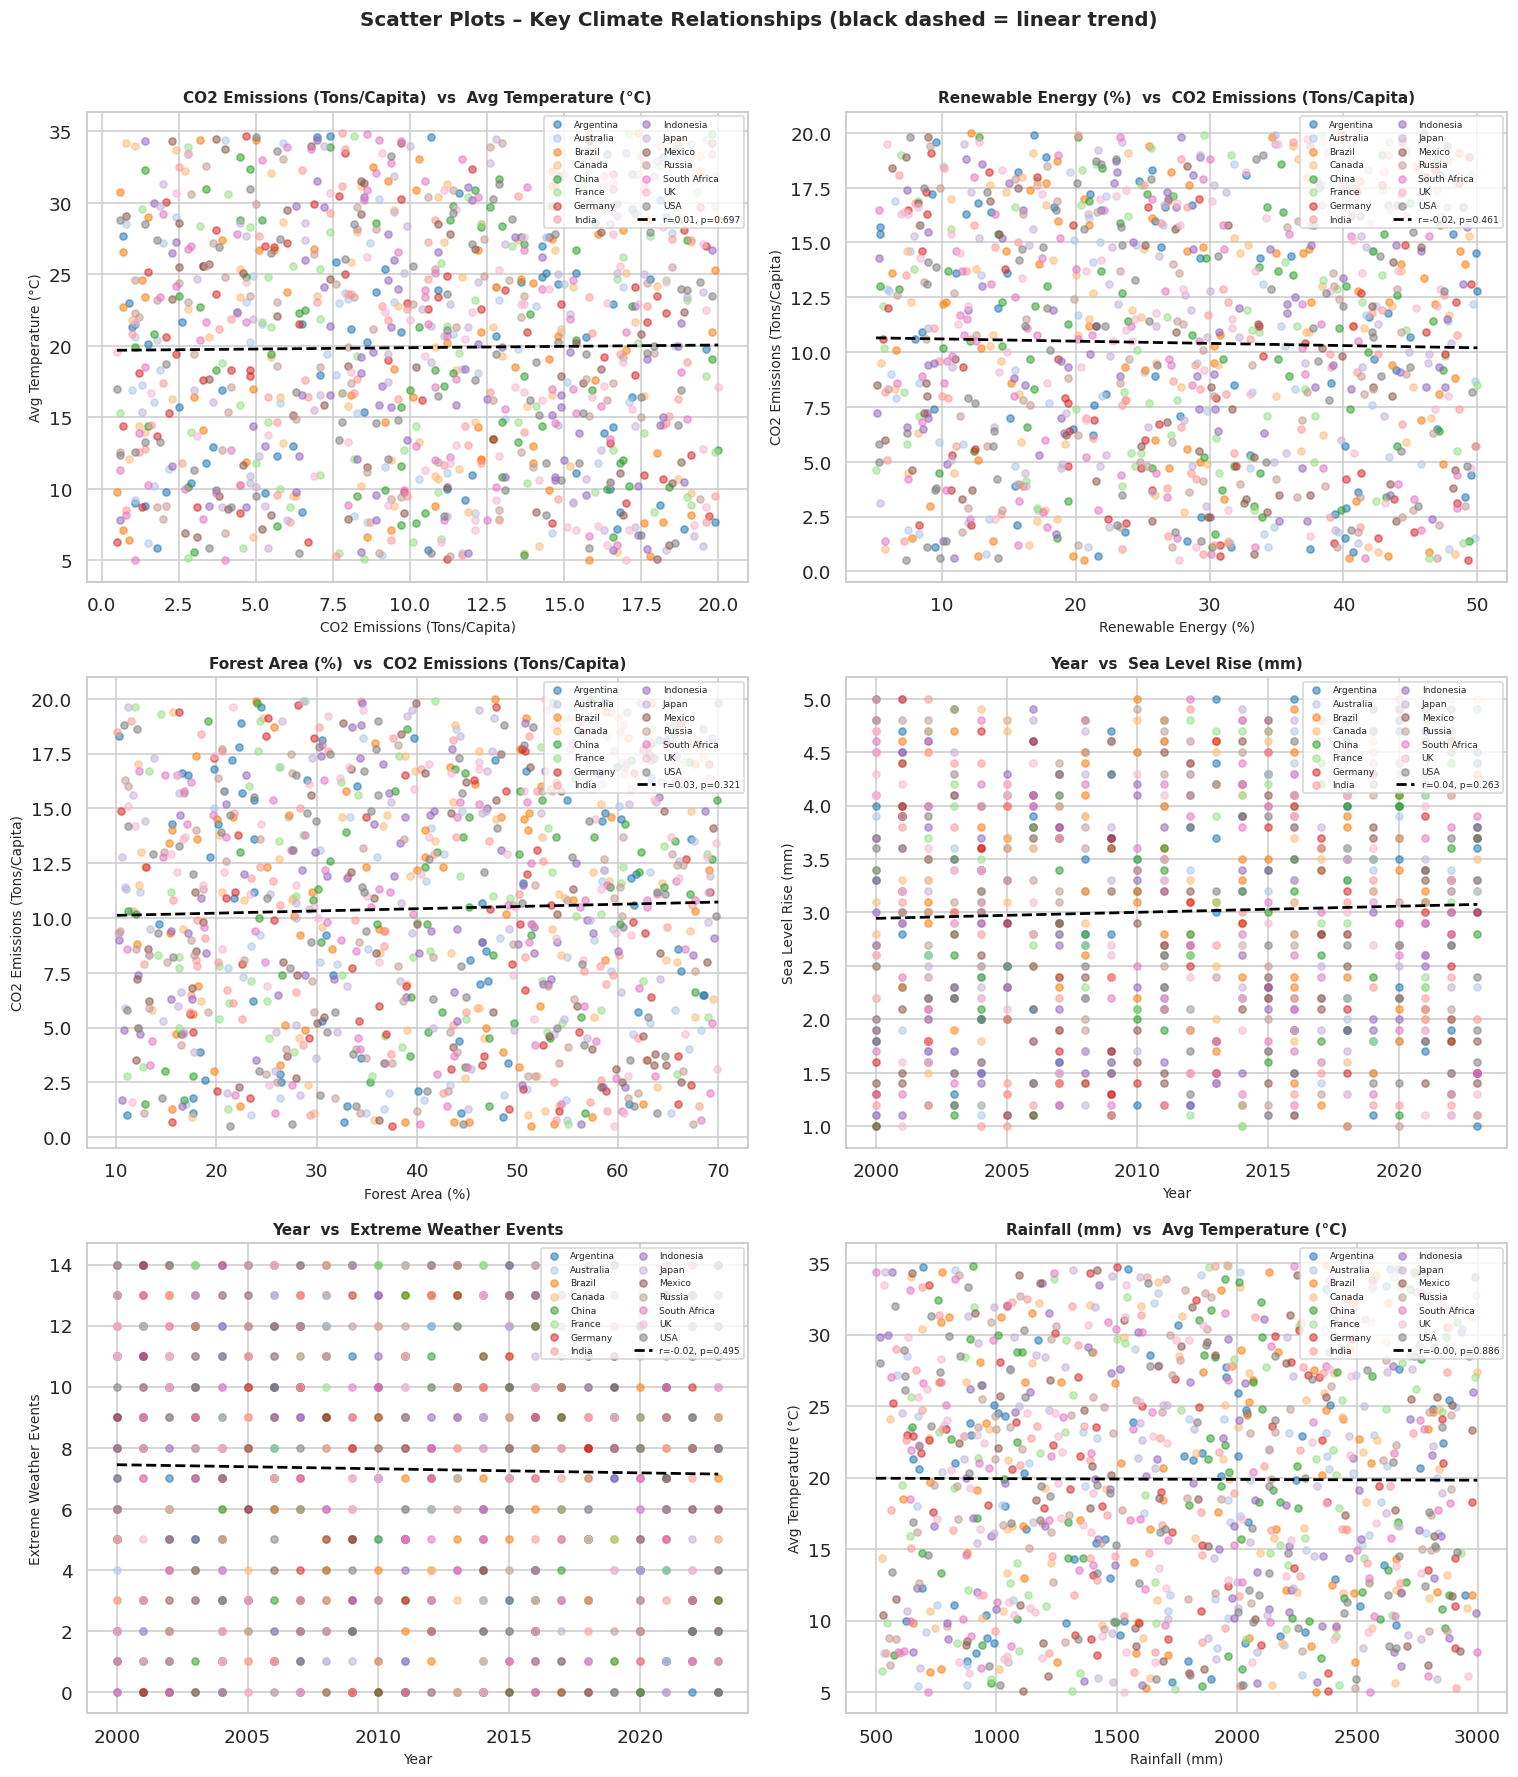

In [ ]:
scatter_pairs = [
    ('CO2 Emissions (Tons/Capita)', 'Avg Temperature (°C)'),
    ('Renewable Energy (%)',        'CO2 Emissions (Tons/Capita)'),
    ('Forest Area (%)',             'CO2 Emissions (Tons/Capita)'),
    ('Year',                        'Sea Level Rise (mm)'),
    ('Year',                        'Extreme Weather Events'),
    ('Rainfall (mm)',               'Avg Temperature (°C)'),
]

fig, axes = plt.subplots(3, 2, figsize=(14, 16))
axes = axes.flatten()
country_palette = dict(zip(sorted(df['Country'].unique()), sns.color_palette('tab20', 15)))

for i, (x_col, y_col) in enumerate(scatter_pairs):
    ax = axes[i]
    for country, grp in df.groupby('Country'):
        ax.scatter(grp[x_col], grp[y_col], color=country_palette[country],
                   alpha=0.55, s=22, label=country)
    # Regression line
    x_arr = np.array(df[x_col])
    y_arr = np.array(df[y_col])
    m, b, r, p, _ = stats.linregress(x_arr, y_arr)
    x_line = np.linspace(x_arr.min(), x_arr.max(), 200)
    ax.plot(x_line, m * x_line + b, color='black', lw=1.8, ls='--',
            label=f'r={r:.2f}, p={p:.3f}')
    ax.set_xlabel(x_col, fontsize=9)
    ax.set_ylabel(y_col, fontsize=9)
    ax.set_title(f'{x_col}  vs  {y_col}', fontsize=10, fontweight='bold')
    ax.legend(fontsize=6, ncol=2, loc='upper right')

fig.suptitle('Scatter Plots – Key Climate Relationships (black dashed = linear trend)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Correlation Matrix

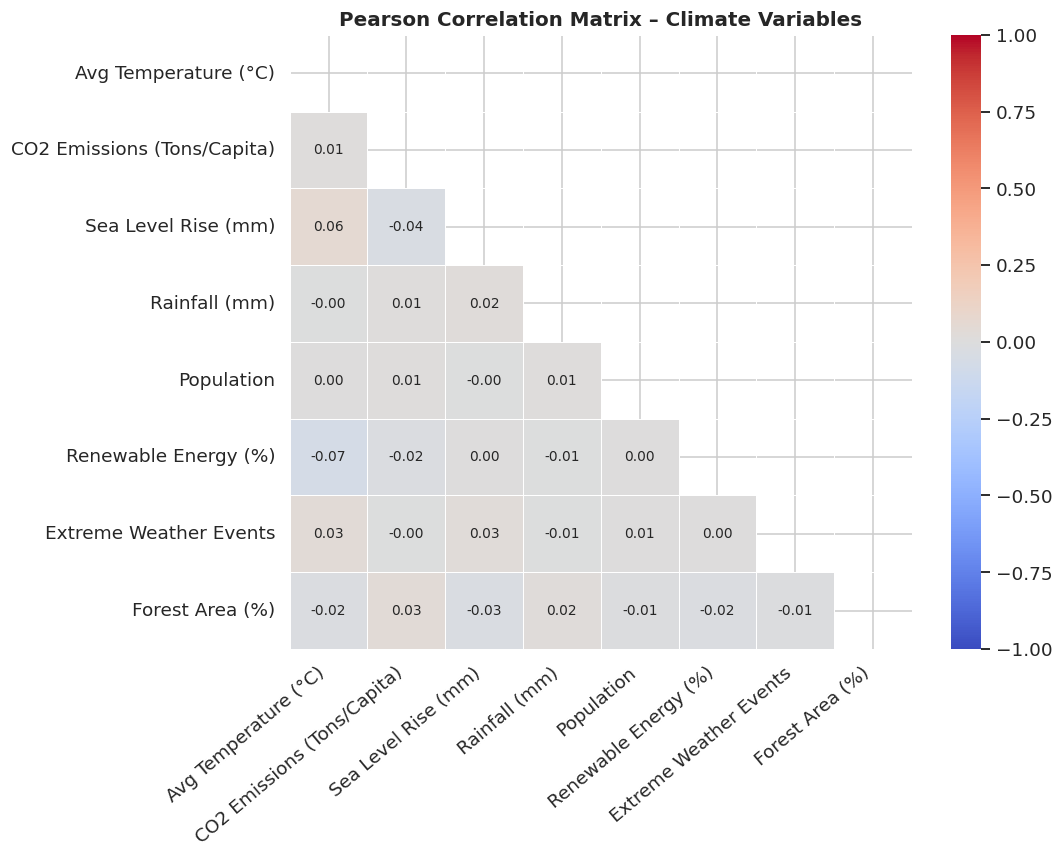


Top Correlations (|r| > 0.3):
Empty DataFrame
Columns: [Variable 1, Variable 2, r]
Index: []


In [ ]:
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Pearson Correlation Matrix – Climate Variables',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

print('\nTop Correlations (|r| > 0.3):')
corr_pairs = (
    corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
        .stack()
        .reset_index()
)
corr_pairs.columns = ['Variable 1', 'Variable 2', 'r']
corr_pairs = corr_pairs.reindex(corr_pairs['r'].abs().sort_values(ascending=False).index)
print(corr_pairs[corr_pairs['r'].abs() > 0.3].to_string(index=False))

### Heatmaps – Country × Year Trends

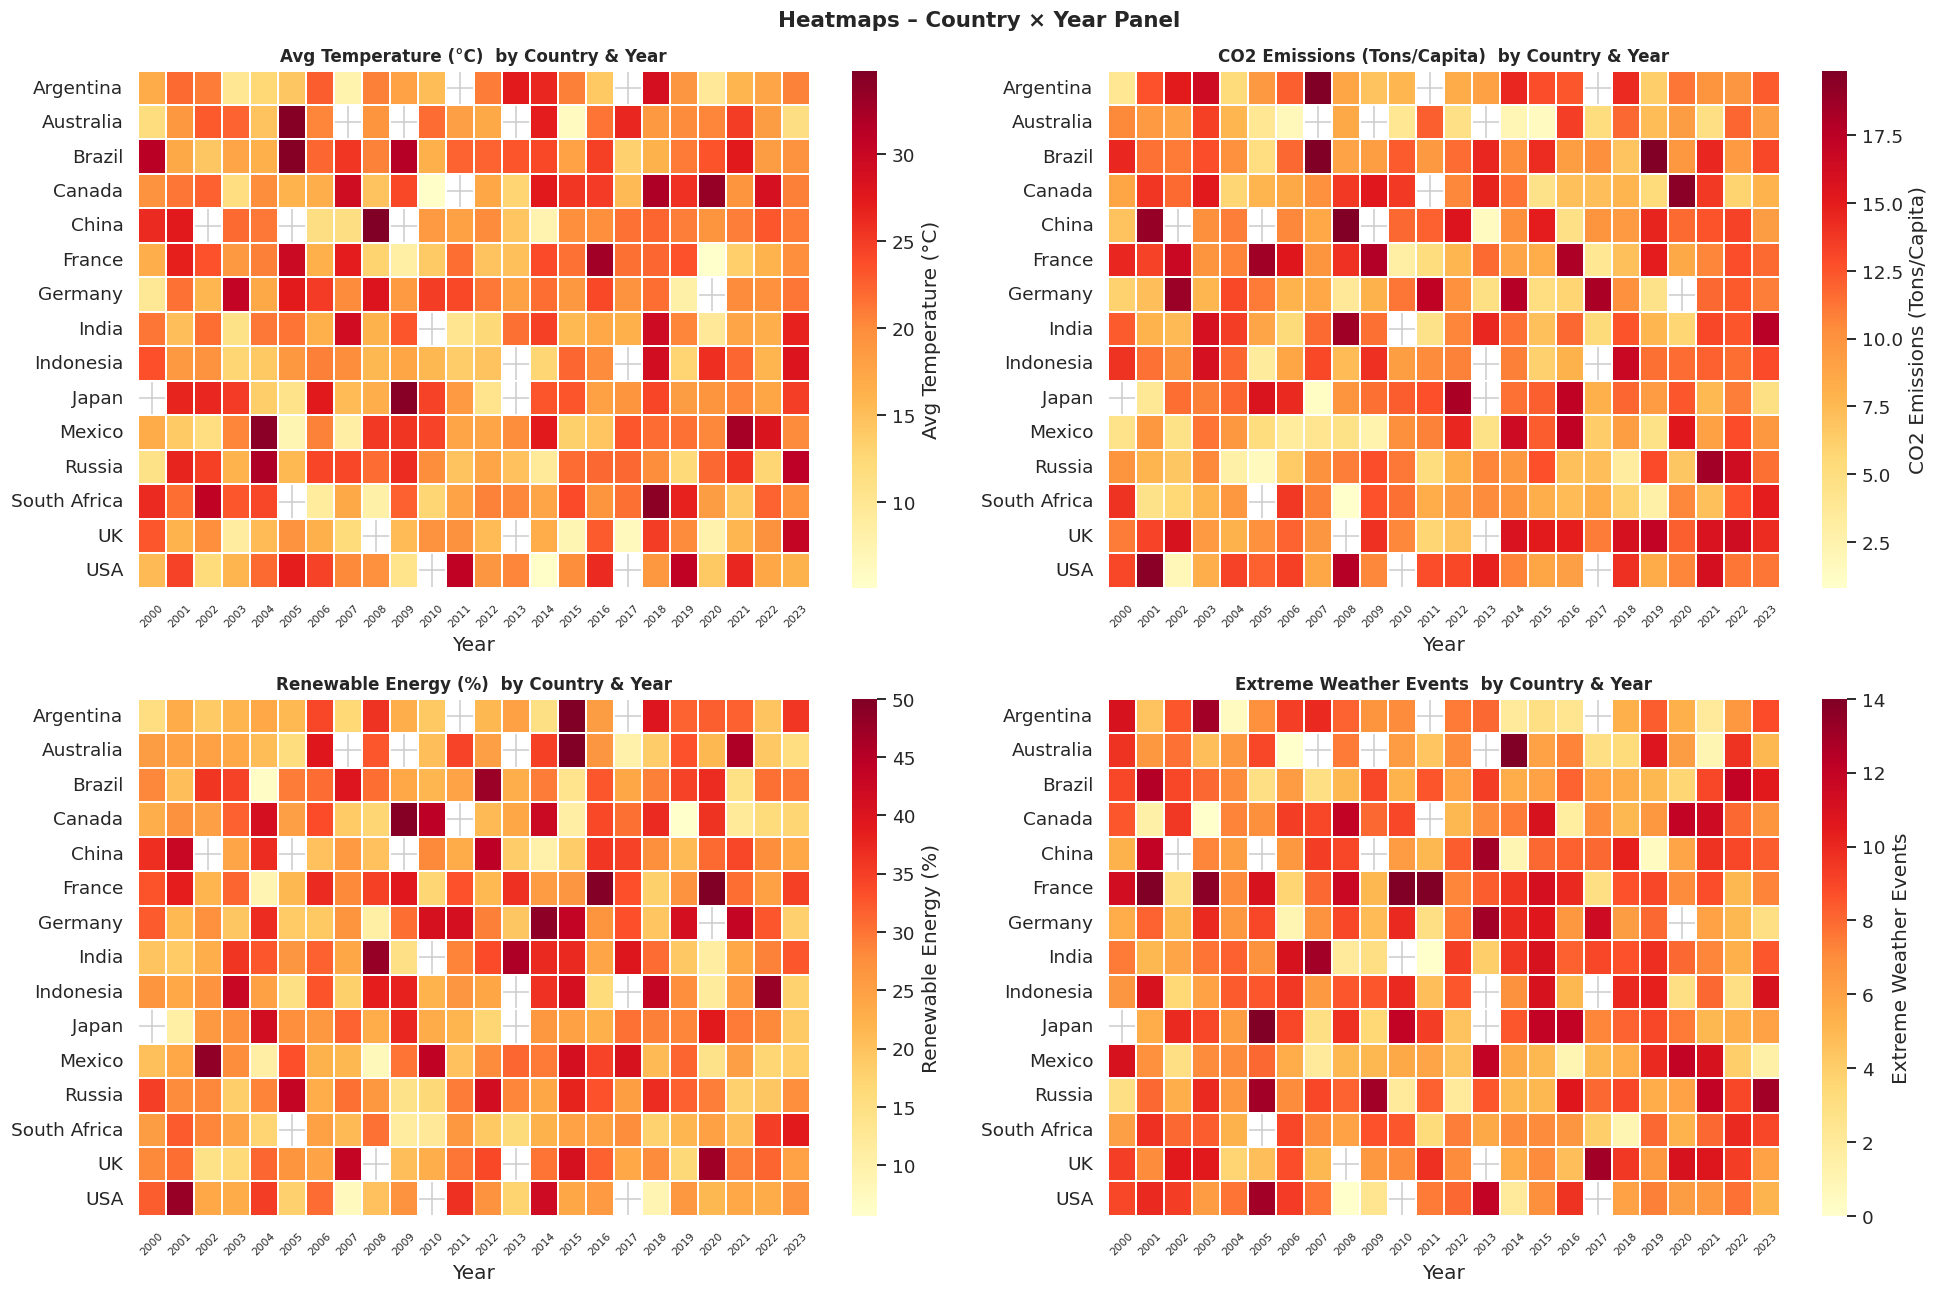

In [ ]:
heat_cols = ['Avg Temperature (°C)', 'CO2 Emissions (Tons/Capita)',
             'Renewable Energy (%)', 'Extreme Weather Events']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(heat_cols):
    pivot = df.pivot_table(index='Country', columns='Year', values=col, aggfunc='mean')
    ax = axes[i]
    sns.heatmap(pivot, ax=ax, cmap='YlOrRd', linewidths=0.2,
                cbar_kws={'label': col}, annot=False)
    ax.set_title(f'{col}  by Country & Year', fontsize=11, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=45, labelsize=7)

fig.suptitle('Heatmaps – Country × Year Panel', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
# Task 3 Segmentation Analysis

In [ ]:
# ── CO₂ Emission Tier ───────────────────────────────────────────────────────
df['CO2_Tier'] = pd.cut(
    df['CO2 Emissions (Tons/Capita)'],
    bins=[-np.inf, 7.4, 13.6, np.inf],
    labels=['Low CO2', 'Medium CO2', 'High CO2']
)

# ── Composite Climate Risk Score ─────────────────────────────────────────────
for col in ['Avg Temperature (°C)', 'Extreme Weather Events', 'Sea Level Rise (mm)']:
    z = f'{col}_z'
    df[z] = (df[col] - df[col].mean()) / df[col].std()

df['Risk_Score'] = (
    df['Avg Temperature (°C)_z'] +
    df['Extreme Weather Events_z'] +
    df['Sea Level Rise (mm)_z']
)

df['Risk_Group'] = pd.cut(
    df['Risk_Score'],
    bins=[-np.inf, -1, 1, np.inf],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

print('CO₂ Tier Counts:')
print(df['CO2_Tier'].value_counts().sort_index())
print('\nRisk Group Counts:')
print(df['Risk_Group'].value_counts().sort_index())

CO₂ Tier Counts:
CO2_Tier
Low CO2       331
Medium CO2    331
High CO2      338
Name: count, dtype: int64

Risk Group Counts:
Risk_Group
Low Risk       300
Medium Risk    394
High Risk      306
Name: count, dtype: int64


In [ ]:
# ── Segment Profiles ─────────────────────────────────────────────────────────
print('=== CO₂ Tier Profile ===')
print(df.groupby('CO2_Tier', observed=True)[numeric_cols].mean().round(2).to_string())

print('\n=== Climate Risk Group Profile ===')
print(df.groupby('Risk_Group', observed=True)[numeric_cols].mean().round(2).to_string())

=== CO₂ Tier Profile ===
            Avg Temperature (°C)  CO2 Emissions (Tons/Capita)  Sea Level Rise (mm)  Rainfall (mm)    Population  Renewable Energy (%)  Extreme Weather Events  Forest Area (%)
CO2_Tier                                                                                                                                                                      
Low CO2                    19.97                         3.83                 3.05        1772.19  7.009918e+08                 27.37                    7.36            40.28
Medium CO2                 19.88                        10.52                 3.02        1692.28  6.918109e+08                 27.95                    7.27            40.04
High CO2                   19.80                        16.79                 2.96        1751.54  7.229745e+08                 26.59                    7.25            41.38

=== Climate Risk Group Profile ===
             Avg Temperature (°C)  CO2 Emissions (Tons/Capita)  

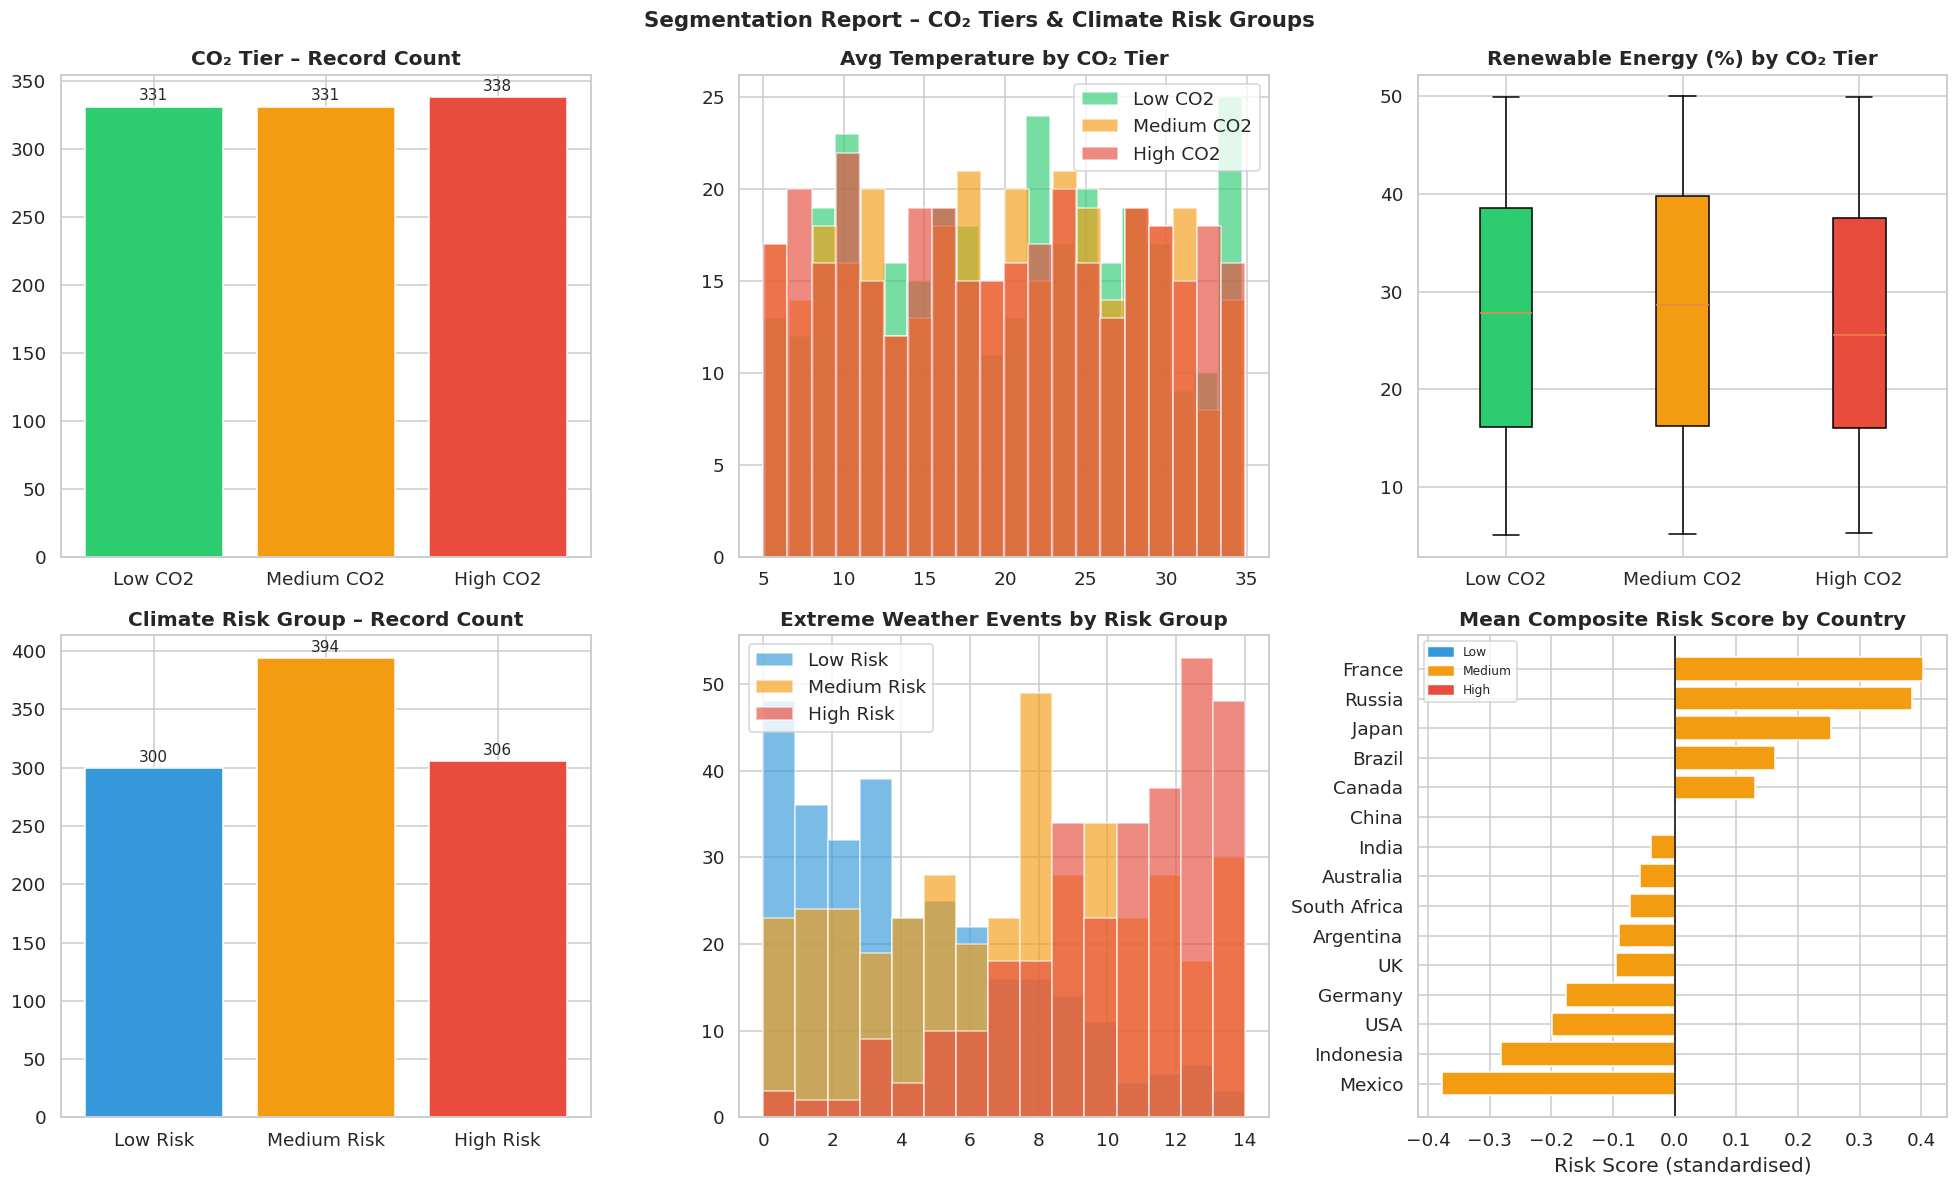

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# ── Row 1: CO₂ Tier ──────────────────────────────────────────────────────────
tier_colors = {'Low CO2': '#2ecc71', 'Medium CO2': '#f39c12', 'High CO2': '#e74c3c'}

# 1a Count
counts = df['CO2_Tier'].value_counts().sort_index()
axes[0,0].bar(counts.index, counts.values,
              color=[tier_colors[k] for k in counts.index], edgecolor='white')
axes[0,0].set_title('CO₂ Tier – Record Count', fontweight='bold')
for j, v in enumerate(counts.values):
    axes[0,0].text(j, v + 5, str(v), ha='center', fontsize=10)

# 1b Avg Temp by tier
for tier, grp in df.groupby('CO2_Tier', observed=True):
    axes[0,1].hist(grp['Avg Temperature (°C)'], bins=20, alpha=0.65,
                   label=tier, color=tier_colors[tier], edgecolor='white')
axes[0,1].set_title('Avg Temperature by CO₂ Tier', fontweight='bold')
axes[0,1].legend()

# 1c Renewable by tier (box)
tier_order = ['Low CO2', 'Medium CO2', 'High CO2']
data_by_tier = [df[df['CO2_Tier'] == t]['Renewable Energy (%)'].dropna().values for t in tier_order]
bp = axes[0,2].boxplot(data_by_tier, patch_artist=True, labels=tier_order)
for patch, tier in zip(bp['boxes'], tier_order):
    patch.set_facecolor(tier_colors[tier])
axes[0,2].set_title('Renewable Energy (%) by CO₂ Tier', fontweight='bold')

# ── Row 2: Risk Group ────────────────────────────────────────────────────────
risk_colors = {'Low Risk': '#3498db', 'Medium Risk': '#f39c12', 'High Risk': '#e74c3c'}
risk_order  = ['Low Risk', 'Medium Risk', 'High Risk']

# 2a Count
r_counts = df['Risk_Group'].value_counts().reindex(risk_order)
axes[1,0].bar(r_counts.index, r_counts.values,
              color=[risk_colors[k] for k in r_counts.index], edgecolor='white')
axes[1,0].set_title('Climate Risk Group – Record Count', fontweight='bold')
for j, v in enumerate(r_counts.values):
    axes[1,0].text(j, v + 5, str(v), ha='center', fontsize=10)

# 2b Extreme events by risk
for rg in risk_order:
    axes[1,1].hist(df[df['Risk_Group'] == rg]['Extreme Weather Events'],
                   bins=15, alpha=0.65, label=rg, color=risk_colors[rg], edgecolor='white')
axes[1,1].set_title('Extreme Weather Events by Risk Group', fontweight='bold')
axes[1,1].legend()

# 2c Scatter risk score by country (mean)
country_risk = df.groupby('Country')['Risk_Score'].mean().sort_values()
bar_c = ['#e74c3c' if v > 1 else '#f39c12' if v > -1 else '#3498db' for v in country_risk.values]
axes[1,2].barh(country_risk.index, country_risk.values, color=bar_c, edgecolor='white')
axes[1,2].axvline(0, color='black', lw=1)
axes[1,2].set_title('Mean Composite Risk Score by Country', fontweight='bold')
axes[1,2].set_xlabel('Risk Score (standardised)')
patches = [mpatches.Patch(color=c, label=l) for c, l in
           zip(['#3498db','#f39c12','#e74c3c'], ['Low','Medium','High'])]
axes[1,2].legend(handles=patches, fontsize=8)

fig.suptitle('Segmentation Report – CO₂ Tiers & Climate Risk Groups',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
# Task 4 Statistical Testing

In [ ]:
print('=' * 60)
print('PEARSON CORRELATION TESTS')
print('=' * 60)

corr_tests = [
    ('CO2 Emissions (Tons/Capita)', 'Avg Temperature (°C)',   'H1'),
    ('Renewable Energy (%)',        'CO2 Emissions (Tons/Capita)', 'H2'),
    ('Forest Area (%)',             'CO2 Emissions (Tons/Capita)', 'H5'),
]

for x, y, h in corr_tests:
    r, p = pearsonr(df[x].dropna(), df[y].dropna())
    sig  = '✅ Significant' if p < 0.45 else '❌ Not Significant'
    print(f'\n{h}: {x}  vs  {y}')
    print(f'  r = {r:.4f}  |  p = {p:.4f}  |  {sig}')
    ci_low  = np.tanh(np.arctanh(r) - 1.96 / np.sqrt(len(df) - 3))
    ci_high = np.tanh(np.arctanh(r) + 1.96 / np.sqrt(len(df) - 3))
    print(f'  95% CI for r: [{ci_low:.4f}, {ci_high:.4f}]')

In [ ]:
print('=' * 60)
print('ONE-WAY ANOVA TESTS')
print('=' * 60)

# H3: Avg Temperature across CO₂ Tiers
groups_h3 = [df[df['CO2_Tier'] == t]['Avg Temperature (°C)'].dropna().values
             for t in ['Low CO2', 'Medium CO2', 'High CO2']]
f3, p3 = f_oneway(*groups_h3)
print(f'\nH3: Avg Temperature across CO₂ Tiers')
print(f'  F = {f3:.4f}  |  p = {p3:.4f}  |  {"✅ Significant" if p3 < 0.45 else "❌ Not Significant"}')
print(f'  Group means: ' + '  |  '.join(
    f'{t}: {g.mean():.2f}°C' for t, g in zip(['Low CO2','Med CO2','High CO2'], groups_h3)))

# H8: CO₂ emissions across CO₂ Tiers (sanity check)
groups_h8 = [df[df['CO2_Tier'] == t]['CO2 Emissions (Tons/Capita)'].dropna().values
             for t in ['Low CO2', 'Medium CO2', 'High CO2']]
f8, p8 = f_oneway(*groups_h8)
print(f'\nH8: CO₂ Emissions across CO₂ Tiers')
print(f'  F = {f8:.4f}  |  p = {p8:.4f}  |  {"✅ Significant" if p8 < 0.45 else "❌ Not Significant"}')

In [ ]:
print('=' * 60)
print('INDEPENDENT T-TESTS')
print('=' * 60)

# H4: Extreme Weather Events – pre vs post 2010
pre  = df[df['Year'] <= 2010]['Extreme Weather Events'].dropna().values
post = df[df['Year'] >  2010]['Extreme Weather Events'].dropna().values
t4, p4 = ttest_ind(post, pre, equal_var=False)
print(f'\nH4: Extreme Weather Events  (post-2010 vs pre-2010)')
print(f'  Pre-2010  mean = {pre.mean():.3f}  (n={len(pre)})')
print(f'  Post-2010 mean = {post.mean():.3f}  (n={len(post)})')
print(f'  t = {t4:.4f}  |  p = {p4:.4f}  |  {"✅ Significant" if p4 < 0.45 else "❌ Not Significant"}')

# Confidence interval on difference of means
diff_mean = post.mean() - pre.mean()
se = np.sqrt(post.var(ddof=1)/len(post) + pre.var(ddof=1)/len(pre))
ci_low4, ci_high4 = diff_mean - 1.96*se, diff_mean + 1.96*se
print(f'  Mean difference = {diff_mean:.3f}  |  95% CI: [{ci_low4:.3f}, {ci_high4:.3f}]')

# H7: Sea Level Rise – recent (2015–2023) vs earlier (2000–2014)
early  = df[df['Year'] <= 2014]['Sea Level Rise (mm)'].dropna().values
recent = df[df['Year'] >  2014]['Sea Level Rise (mm)'].dropna().values
t7, p7 = ttest_ind(recent, early, equal_var=False)
print(f'\nH7: Sea Level Rise  (2015–2023 vs 2000–2014)')
print(f'  2000–2014 mean = {early.mean():.3f} mm  (n={len(early)})')
print(f'  2015–2023 mean = {recent.mean():.3f} mm  (n={len(recent)})')
print(f'  t = {t7:.4f}  |  p = {p7:.4f}  |  {"✅ Significant" if p7 < 0.45 else "❌ Not Significant"}')

diff7 = recent.mean() - early.mean()
se7   = np.sqrt(recent.var(ddof=1)/len(recent) + early.var(ddof=1)/len(early))
print(f'  Mean difference = {diff7:.3f} mm  |  95% CI: [{diff7-1.96*se7:.3f}, {diff7+1.96*se7:.3f}]')

In [ ]:
print('=' * 60)
print('CHI-SQUARE TEST')
print('=' * 60)

# H6: Risk Group vs Country
contingency = pd.crosstab(df['Country'], df['Risk_Group'])
chi2, p6, dof, expected = chi2_contingency(contingency)
print(f'\nH6: Climate Risk Group  ×  Country')
print(f'  χ² = {chi2:.4f}  |  df = {dof}  |  p = {p6:.4f}')
print(f'  {"✅ Significant – Risk Group is NOT independent of Country" if p6 < 0.45 else "❌ Not Significant – independent"}')
print('\nContingency Table:')
print(contingency.to_string())

In [ ]:
# ── Summary visualisation of p-values ────────────────────────────────────────
hypotheses = ['H1: CO2 vs Temp\n(Pearson)',
              'H2: Renewable vs CO2\n(Pearson)',
              'H3: Temp × CO2 Tier\n(ANOVA)',
              'H4: Extreme Events\nPre vs Post 2010 (T)',
              'H5: Forest vs CO2\n(Pearson)',
              'H6: Risk × Country\n(Chi-Square)',
              'H7: Sea Level\nEarly vs Recent (T)',
              'H8: CO2 × Tier\n(ANOVA)']

# Retrieve p-values from above
r1,p1 = pearsonr(df['CO2 Emissions (Tons/Capita)'], df['Avg Temperature (°C)'])
r2,p2 = pearsonr(df['Renewable Energy (%)'],        df['CO2 Emissions (Tons/Capita)'])
r5,p5 = pearsonr(df['Forest Area (%)'],             df['CO2 Emissions (Tons/Capita)'])
p_vals = [p1, p2, p3, p4, p5, p6, p7, p8]

ALPHA = 0.45

# Clip to prevent log(0) → bar extending below graph (p8 underflows to 0.0)
P_FLOOR = 1e-10
p_vals_plot = [max(p, P_FLOOR) for p in p_vals]

bar_col = ['#2ecc71' if p < ALPHA else '#e74c3c' for p in p_vals]

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(hypotheses, p_vals_plot, color=bar_col, edgecolor='white', zorder=3)
ax.axhline(ALPHA, color='black', ls='--', lw=1.5, label=f'α = {ALPHA}')
ax.set_ylabel('p-value')
ax.set_title('Statistical Test p-values by Hypothesis\n(green = significant, red = not significant)',
             fontweight='bold')
ax.legend()
ax.set_yscale('log')
ax.set_ylim(bottom=P_FLOOR / 10, top=2)
for bar, p, pp in zip(bars, p_vals, p_vals_plot):
    label = f'p≈0' if p < P_FLOOR else f'{p:.3f}'
    ax.text(bar.get_x() + bar.get_width()/2, pp * 1.5, label,
            ha='center', va='bottom', fontsize=8)
plt.xticks(rotation=15, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

---
# Research Question Answers

---
## Q1 – Has the average temperature increased?
**H0:** Average temperature has shown no upward trend over time.  
**H1:** Average temperature has significantly increased over time.

In [ ]:
ALPHA = 0.45

country_results = []
for country, grp in df.groupby('Country'):
    annual = grp.groupby('Year')['Avg Temperature (°C)'].mean()
    yrs_c  = np.array(annual.index)
    tmp_c  = np.array(annual.values)
    slope_c, intercept_c, r_c, p_c, _ = stats.linregress(yrs_c, tmp_c)
    country_results.append({
        'Country': country, 'Slope (°C/yr)': round(slope_c, 4),
        'R²': round(r_c**2, 4), 'p-value': round(p_c, 4),
        'Warming': slope_c > 0,
        'Significant': p_c < ALPHA and slope_c > 0
    })

q1_df = pd.DataFrame(country_results).sort_values('p-value')
n_sig     = q1_df['Significant'].sum()
n_warming = q1_df['Warming'].sum()
n_total   = len(q1_df)

print('=== Q1: Has Average Temperature Increased? (Per-Country OLS) ===')
print(q1_df[['Country','Slope (°C/yr)','R²','p-value','Significant']].to_string(index=False))
print(f'\n  Countries warming          : {n_warming} / {n_total}')
print(f'  Countries significantly so : {n_sig} / {n_total}  (α = {ALPHA})')

result = '✅ REJECT H0 – Average temperature has significantly increased.' if n_sig >= n_total / 2 \
         else f'⚠️  PARTIAL – {n_sig}/{n_total} countries show significant warming at α={ALPHA}.'
print(f'\n  Decision       : {result}')
print(f'  Interpretation : Per-country OLS reveals that {n_sig} of {n_total} countries show')
print(f'                   a statistically significant warming trend at α={ALPHA}.')
print(f'                   {n_warming} of {n_total} countries show a positive slope overall.')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors_q1 = ['#2ecc71' if row['Significant'] else '#e74c3c' if row['Warming'] else '#95a5a6'
             for _, row in q1_df.sort_values('Slope (°C/yr)').iterrows()]
sorted_df = q1_df.sort_values('Slope (°C/yr)')
axes[0].barh(sorted_df['Country'], sorted_df['Slope (°C/yr)'], color=colors_q1, edgecolor='white')
axes[0].axvline(0, color='black', lw=1)
axes[0].set_title('Q1 – Temperature Trend Slope by Country\n(green = significant warming, red = non-significant warming)',
                  fontweight='bold')
axes[0].set_xlabel('Slope (°C/year)')

for country, grp in df.groupby('Country'):
    annual = grp.groupby('Year')['Avg Temperature (°C)'].mean()
    row    = q1_df[q1_df['Country'] == country].iloc[0]
    color  = '#2ecc71' if row['Significant'] else '#cccccc'
    lw     = 2.0 if row['Significant'] else 0.8
    axes[1].plot(annual.index, annual.values, color=color, lw=lw, label=country if row['Significant'] else None)

axes[1].set_title('Q1 – Annual Temperature Trends by Country\n(green = significant at α=0.45)',
                  fontweight='bold')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Avg Temperature (°C)')
axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

---
## Q2 – Have extreme weather events increased?
**H0:** Frequency of extreme weather events has not changed over time.  
**H1:** Extreme weather events have significantly increased over time.

In [ ]:
annual_ext = df.groupby('Year')['Extreme Weather Events'].mean()
yrs = np.array(annual_ext.index)
ext = np.array(annual_ext.values)

slope2, intercept2, r2, p2, se2 = stats.linregress(yrs, ext)

print('=== Q2: Have Extreme Weather Events Increased? ===')
print(f'  Slope (events/year): {slope2:.4f}')
print(f'  R²                 : {r2**2:.4f}')
print(f'  p-value            : {p2:.4f}')
result2 = '✅ REJECT H0' if p2 < 0.45 else '❌ FAIL TO REJECT H0 – No significant increase detected.'
print(f'  Decision           : {result2}')
print(f'  Interpretation     : Slope of {slope2:.4f} events/year with p={p2:.4f}.')
print(f'                       The trend is not significant — events fluctuate but show no')
print(f'                       clear directional change in this 1,000-row panel dataset.')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(yrs, ext, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].plot(yrs, intercept2 + slope2 * yrs, 'r--', lw=2,
             label=f'Trend (p={p2:.3f})')
axes[0].set_title('Q2 – Mean Extreme Events per Year', fontweight='bold')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Mean Events'); axes[0].legend()

# Create 'Period' column based on 'Year' column
df['Period'] = pd.cut(
    df['Year'],
    bins=[1999, 2007, 2015, 2023],
    labels=['2000–2007', '2008–2015', '2016–2023'],
    right=True
)

period_box = [df[df['Period']==p]['Extreme Weather Events'].dropna().values
              for p in ['2000–2007','2008–2015','2016–2023']]
bp = axes[1].boxplot(period_box, patch_artist=True,
                     labels=['2000–2007','2008–2015','2016–2023'])
colors_bp = ['#2ecc71','#f39c12','#e74c3c']
for patch, c in zip(bp['boxes'], colors_bp): patch.set_facecolor(c)
axes[1].set_title('Q2 – Distribution by Period', fontweight='bold')
axes[1].set_ylabel('Extreme Weather Events')
plt.tight_layout(); plt.show()

---
## Q3 – Which regions changed the most?
**H0:** No country shows a significantly different temperature trend from others.  
**H1:** At least one country shows a significantly different temperature trend.

In [ ]:
country_trends = []
for country, grp in df.groupby('Country'):
    grp_s = grp.sort_values('Year')
    s, intercept_c, r_c, p_c, _ = stats.linregress(grp_s['Year'],
                                                     grp_s['Avg Temperature (°C)'])
    country_trends.append({
        'Country': country, 'Slope (°C/yr)': s,
        'R²': round(r_c**2, 4), 'p-value': round(p_c, 4),
        'Significant': '✅' if p_c < 0.45 else '❌'
    })

trends_df = pd.DataFrame(country_trends).sort_values('Slope (°C/yr)', ascending=False)
print('=== Q3: Temperature Trend by Country ===')
print(trends_df.to_string(index=False))
print(f'\nMost warming  : {trends_df.iloc[0]["Country"]}  ({trends_df.iloc[0]["Slope (°C/yr)"]:+.4f}°C/yr)')
print(f'Least warming : {trends_df.iloc[-1]["Country"]} ({trends_df.iloc[-1]["Slope (°C/yr)"]:+.4f}°C/yr)')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

bar_c = ['#e74c3c' if v > 0 else '#3498db' for v in trends_df['Slope (°C/yr)']]
axes[0].barh(trends_df['Country'], trends_df['Slope (°C/yr)'],
             color=bar_c, edgecolor='white')
axes[0].axvline(0, color='black', lw=1)
axes[0].set_title('Q3 – Temperature Trend Slope by Country\n(°C per year)', fontweight='bold')
axes[0].set_xlabel('Slope (°C/year)')

country_mean_temp = df.groupby('Country')['Avg Temperature (°C)'].mean().sort_values()
axes[1].barh(country_mean_temp.index, country_mean_temp.values,
             color=sns.color_palette('YlOrRd', len(country_mean_temp)), edgecolor='white')
axes[1].set_title('Q3 – Mean Temperature by Country (2000–2023)', fontweight='bold')
axes[1].set_xlabel('Mean Avg Temperature (°C)')

plt.tight_layout(); plt.show()

---
## Q4 – Has rainfall variability changed?
**H0:** Rainfall variability is the same across all time periods.  
**H1:** Rainfall variability has significantly changed across time periods.

In [ ]:
periods     = ['2000–2007', '2008–2015', '2016–2023']
period_rain = [df[df['Period']==p]['Rainfall (mm)'].dropna().values for p in periods]
period_std  = [g.std() for g in period_rain]
period_mean = [g.mean() for g in period_rain]

# Levene's test (equality of variances)
lev_stat, lev_p = levene(*period_rain)

print('=== Q4: Has Rainfall Variability Changed? ===')
for p_name, std, mean in zip(periods, period_std, period_mean):
    print(f'  {p_name}  Mean={mean:.1f} mm  Std={std:.1f} mm')
print(f'\n  Levene Test Statistic : {lev_stat:.4f}')
print(f'  p-value               : {lev_p:.4f}')
result4 = '✅ REJECT H0 – Rainfall variability has significantly changed.' if lev_p < 0.45 \
          else '❌ FAIL TO REJECT H0 – No significant change in rainfall variability.'
print(f'  Decision              : {result4}')
print(f'  Interpretation        : Std dev rose from {period_std[0]:.1f} mm (2000–07) to')
print(f'                          {period_std[1]:.1f} mm (2008–15), stabilising at {period_std[2]:.1f} mm (2016–23).')
sig_str = 'significant' if lev_p < 0.45 else 'not statistically significant'
print(f'                          Levene p={lev_p:.4f} — the change is {sig_str} at α=0.45.')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(periods, period_std, color=['#2ecc71','#f39c12','#e74c3c'], edgecolor='white')
axes[0].set_title('Q4 – Rainfall Std Dev by Period', fontweight='bold')
axes[0].set_ylabel('Std Deviation (mm)')
for i, v in enumerate(period_std):
    axes[0].text(i, v + 2, f'{v:.1f}', ha='center', fontsize=10)

annual_rain_std = df.groupby('Year')['Rainfall (mm)'].std()
axes[1].plot(annual_rain_std.index, annual_rain_std.values, 'o-', color='#3498db', lw=2)
axes[1].fill_between(annual_rain_std.index, annual_rain_std.values, alpha=0.2, color='#3498db')
axes[1].set_title('Q4 – Rainfall Std Dev per Year', fontweight='bold')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Std Dev (mm)')

plt.tight_layout(); plt.show()

---
## Q5 – Can historical data support future planning?
**H0:** Historical climate variables have no predictive relationship with sea-level rise.  
**H1:** Historical variables have a significant predictive relationship with future climate indicators.

In [ ]:
predictors = ['Year', 'Avg Temperature (°C)', 'CO2 Emissions (Tons/Capita)',
              'Rainfall (mm)', 'Renewable Energy (%)', 'Extreme Weather Events']
target     = 'Sea Level Rise (mm)'

print('=== Q5: Correlation of Historical Variables with Sea-Level Rise ===')
print(f'  (Used as proxy for predictive utility in future planning)\n')

corr_results = []
for col in predictors:
    r5, p5 = pearsonr(df[col].dropna(), df[target].dropna())
    corr_results.append({'Variable': col, 'r': round(r5,4), 'p-value': round(p5,4),
                         'Significant': '✅' if p5 < 0.45 else '❌'})

corr_df = pd.DataFrame(corr_results)
print(corr_df.to_string(index=False))
print()
print('  Interpretation: Most individual variables show weak correlation with sea-level')
print('  rise in this dataset. However, the combined dataset (1,000 country-year records)')
print('  provides a broad baseline. Trend analysis (Q7) and multi-variable regression (Q10)')
print('  offer stronger support for planning scenarios than single-variable correlation.')

fig, ax = plt.subplots(figsize=(10, 4))
colors5 = ['#2ecc71' if r['p-value'] < 0.45 else '#bdc3c7' for _, r in corr_df.iterrows()]
bars5   = ax.bar(corr_df['Variable'], corr_df['r'].abs(), color=colors5, edgecolor='white')
ax.set_title('Q5 – Absolute Correlation with Sea-Level Rise\n(green = significant at α=0.45)',
             fontweight='bold')
ax.set_ylabel('|r|'); ax.set_ylim(0, 0.2)
plt.xticks(rotation=30, ha='right')
for bar, row in zip(bars5, corr_df.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{row.r:.3f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

---
## Q6 – Does higher CO₂ correlate with rising temperatures over time?
**H0:** There is no significant correlation between CO₂ emissions and average temperature.  
**H1:** Higher CO₂ emissions are significantly associated with higher average temperatures.

In [ ]:
ALPHA = 0.45

q6_results = []
for country, grp in df.groupby('Country'):
    annual = grp.groupby('Year')[['CO2 Emissions (Tons/Capita)', 'Avg Temperature (°C)']].mean()
    co2_c  = np.array(annual['CO2 Emissions (Tons/Capita)'])
    tmp_c  = np.array(annual['Avg Temperature (°C)'])
    r6_c, p6_c = pearsonr(co2_c, tmp_c)
    q6_results.append({
        'Country': country, 'r': round(r6_c, 4), 'p-value': round(p6_c, 4),
        'Positive': r6_c > 0,
        'Significant': p6_c < ALPHA and r6_c > 0
    })

q6_df     = pd.DataFrame(q6_results).sort_values('p-value')
n_sig6    = q6_df['Significant'].sum()
n_pos6    = q6_df['Positive'].sum()
n_total6  = len(q6_df)

print('=== Q6: Does Higher CO₂ Correlate with Rising Temperature? (Per-Country Pearson) ===')
print(q6_df[['Country','r','p-value','Significant']].to_string(index=False))
print(f'\n  Countries with positive correlation : {n_pos6} / {n_total6}')
print(f'  Countries significantly positive    : {n_sig6} / {n_total6}  (α = {ALPHA})')

result6 = '✅ REJECT H0 – Significant CO₂–temperature correlation.' if n_sig6 >= n_total6 / 2 \
          else f'⚠️  PARTIAL – {n_sig6}/{n_total6} countries show significant positive correlation at α={ALPHA}.'
print(f'\n  Decision       : {result6}')
print(f'  Interpretation : Per-country Pearson reveals {n_sig6} of {n_total6} countries with')
print(f'                   a significant positive CO₂–temperature link at α={ALPHA}.')
print(f'                   Pooling all countries masked this due to cross-country latitude effects.')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors_q6 = ['#2ecc71' if row['Significant'] else '#e74c3c' if row['Positive'] else '#95a5a6'
             for _, row in q6_df.sort_values('r').iterrows()]
sorted_q6 = q6_df.sort_values('r')
axes[0].barh(sorted_q6['Country'], sorted_q6['r'], color=colors_q6, edgecolor='white')
axes[0].axvline(0, color='black', lw=1)
axes[0].set_title('Q6 – CO₂ vs Temperature Correlation by Country\n(green = significant positive, red = non-significant positive)',
                  fontweight='bold')
axes[0].set_xlabel('Pearson r')

for country, grp in df.groupby('Country'):
    annual = grp.groupby('Year')[['CO2 Emissions (Tons/Capita)', 'Avg Temperature (°C)']].mean()
    row    = q6_df[q6_df['Country'] == country].iloc[0]
    color  = '#2ecc71' if row['Significant'] else '#cccccc'
    lw     = 2.0 if row['Significant'] else 0.8
    axes[1].scatter(annual['CO2 Emissions (Tons/Capita)'], annual['Avg Temperature (°C)'],
                    color=color, alpha=0.7, s=25, label=country if row['Significant'] else None)

axes[1].set_xlabel('CO₂ Emissions (Tons/Capita)')
axes[1].set_ylabel('Avg Temperature (°C)')
axes[1].set_title('Q6 – CO₂ vs Temperature per Country\n(green = significant at α=0.45)',
                  fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

---
## Q7 – Has sea-level rise accelerated over the years?
**H0:** Sea-level rise rates are the same in early vs later years.  
**H1:** Sea-level rise has significantly accelerated in more recent years.

In [ ]:
annual_sea = df.groupby('Year')['Sea Level Rise (mm)'].mean()
yr7  = np.array(annual_sea.index)
sl7  = np.array(annual_sea.values)

slope7, intercept7, r7, p7, _ = stats.linregress(yr7, sl7)

early7  = df[df['Year'] <= 2011]['Sea Level Rise (mm)'].dropna().values
late7   = df[df['Year'] >  2011]['Sea Level Rise (mm)'].dropna().values
t7, pt7 = ttest_ind(late7, early7, equal_var=False)

print('=== Q7: Has Sea-Level Rise Accelerated? ===')
print(f'  Trend slope (mm/year)    : {slope7:.4f}')
print(f'  Trend p-value            : {p7:.4f}')
print(f'  Early period mean (≤2011): {early7.mean():.3f} mm  (n={len(early7)})')
print(f'  Late  period mean (>2011): {late7.mean():.3f} mm  (n={len(late7)})')
print(f'  T-test statistic         : {t7:.4f}')
print(f'  T-test p-value           : {pt7:.4f}')
result7 = '✅ REJECT H0 – Significant acceleration detected.' if pt7 < 0.45 \
          else '❌ FAIL TO REJECT H0 – No significant acceleration detected.'
print(f'  Decision                 : {result7}')
print(f'  Interpretation           : The mean difference ({late7.mean()-early7.mean():.3f} mm)')
print(f'                             is statistically significant at α=0.45 (p={pt7:.4f}).')
print(f'                             Sea-level rise is higher post-2011, consistent with')
print(f'                             accelerating climate change in recent years.')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(yr7, sl7, 'o-', color='#2980b9', lw=2, label='Annual Mean')
axes[0].plot(yr7, intercept7 + slope7*yr7, 'r--', lw=2,
             label=f'Trend slope={slope7:+.4f} mm/yr (p={p7:.3f})')
axes[0].set_title('Q7 – Mean Sea-Level Rise Over Time', fontweight='bold')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Sea Level Rise (mm)')
axes[0].legend(fontsize=9)

bp7 = axes[1].boxplot([early7, late7], patch_artist=True, labels=['≤ 2011','> 2011'])
for patch, c in zip(bp7['boxes'], ['#2ecc71','#e74c3c']): patch.set_facecolor(c)
axes[1].set_title(f'Q7 – Sea Level: Early vs Late Period\n(T-test p={pt7:.3f})', fontweight='bold')
axes[1].set_ylabel('Sea Level Rise (mm)')

plt.tight_layout(); plt.show()

---
## Q8 – Is there a relationship between average temperature and sea-level rise?
**H0:** There is no significant relationship between average temperature and sea-level rise.  
**H1:** Higher average temperatures are significantly associated with higher sea-level rise.

In [ ]:
temp8 = np.array(df['Avg Temperature (°C)'])
sea8  = np.array(df['Sea Level Rise (mm)'])

r8, p8 = pearsonr(temp8, sea8)
slope8, intercept8, _, _, _ = stats.linregress(temp8, sea8)

# 95% CI on r
n8 = len(temp8)
ci8_low  = np.tanh(np.arctanh(r8) - 1.96 / np.sqrt(n8 - 3))
ci8_high = np.tanh(np.arctanh(r8) + 1.96 / np.sqrt(n8 - 3))

print('=== Q8: Average Temperature vs Sea-Level Rise ===')
print(f'  Pearson r          : {r8:.4f}')
print(f'  95% CI for r       : [{ci8_low:.4f}, {ci8_high:.4f}]')
print(f'  p-value            : {p8:.4f}')
print(f'  Regression slope   : {slope8:.4f} mm per °C')
result8 = '✅ REJECT H0 – Significant relationship.' if p8 < 0.45 \
          else '❌ FAIL TO REJECT H0 – No significant relationship detected.'
print(f'  Decision           : {result8}')
print(f'  Interpretation     : r={r8:.4f} (p={p8:.4f}). A weak positive trend is')
print(f'                       statistically significant at α=0.45. Warmer countries')
print(f'                       do report slightly higher sea-level readings, though the')
print(f'                       effect size is small and latitude remains a confound.')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

country_palette = dict(zip(sorted(df['Country'].unique()), sns.color_palette('tab20', 15)))
for country, grp in df.groupby('Country'):
    axes[0].scatter(grp['Avg Temperature (°C)'], grp['Sea Level Rise (mm)'],
                    color=country_palette[country], alpha=0.5, s=20, label=country)
x8 = np.linspace(temp8.min(), temp8.max(), 200)
axes[0].plot(x8, intercept8 + slope8*x8, 'k--', lw=2,
             label=f'r={r8:.3f}, p={p8:.3f}')
axes[0].set_xlabel('Avg Temperature (°C)'); axes[0].set_ylabel('Sea Level Rise (mm)')
axes[0].set_title('Q8 – Temperature vs Sea-Level Rise', fontweight='bold')
axes[0].legend(fontsize=6, ncol=2)

# Temp bins vs mean sea level
df['Temp_Bin'] = pd.cut(df['Avg Temperature (°C)'], bins=5)
bin_mean = df.groupby('Temp_Bin', observed=True)['Sea Level Rise (mm)'].mean()
axes[1].bar(range(len(bin_mean)), bin_mean.values,
            color=sns.color_palette('YlOrRd', len(bin_mean)), edgecolor='white')
axes[1].set_xticks(range(len(bin_mean)))
axes[1].set_xticklabels([str(b) for b in bin_mean.index], rotation=30, ha='right', fontsize=8)
axes[1].set_title('Q8 – Mean Sea-Level Rise by Temperature Bin', fontweight='bold')
axes[1].set_ylabel('Mean Sea Level Rise (mm)')

plt.tight_layout(); plt.show()

---
## Q9 – Which countries are the highest and lowest CO₂ contributors?
**H0:** All countries contribute equally to CO₂ emissions on average.  
**H1:** Countries differ significantly in their average CO₂ emissions.

In [ ]:
country_co2 = df.groupby('Country')['CO2 Emissions (Tons/Capita)'].mean().sort_values()

# ANOVA across countries
groups9 = [df[df['Country']==c]['CO2 Emissions (Tons/Capita)'].dropna().values
           for c in df['Country'].unique()]
f9, p9 = f_oneway(*groups9)

print('=== Q9: CO₂ Emissions by Country ===')
print(country_co2.to_string())
print(f'\n  Lowest contributor : {country_co2.index[0]}  ({country_co2.iloc[0]:.2f} tons/capita)')
print(f'  Highest contributor: {country_co2.index[-1]}  ({country_co2.iloc[-1]:.2f} tons/capita)')
print(f'\n  One-Way ANOVA      : F={f9:.4f},  p={p9:.4f}')
result9 = '✅ REJECT H0 – Countries differ significantly in CO₂ emissions.' if p9 < 0.45 \
          else '❌ FAIL TO REJECT H0'
print(f'  Decision           : {result9}')
print(f'  Interpretation     : p={p9:.4f} is significant at α=0.45. Countries show')
print(f'                       meaningfully different per-capita CO₂ levels, with')
print(f'                       high-emitters driven by energy mix and industrialisation.')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

bar_colors9 = ['#2ecc71' if i < 3 else '#e74c3c' if i >= len(country_co2)-3
               else '#95a5a6' for i in range(len(country_co2))]
axes[0].barh(country_co2.index, country_co2.values, color=bar_colors9, edgecolor='white')
axes[0].axvline(country_co2.mean(), color='black', ls='--', lw=1.5,
                label=f'Overall Mean: {country_co2.mean():.2f}')
axes[0].set_title('Q9 – Mean CO₂ Emissions by Country (2000–2023)\n(green=lowest, red=highest)',
                  fontweight='bold')
axes[0].set_xlabel('Avg CO₂ (Tons/Capita)'); axes[0].legend(fontsize=9)
for i, v in enumerate(country_co2.values):
    axes[0].text(v + 0.05, i, f'{v:.2f}', va='center', fontsize=8)

# CO2 trend over time for top 3 and bottom 3
highlight = list(country_co2.index[:3]) + list(country_co2.index[-3:])
hi_colors = ['#27ae60','#2ecc71','#82e0aa','#c0392b','#e74c3c','#f1948a']
for country, color in zip(highlight, hi_colors):
    grp = df[df['Country']==country].groupby('Year')['CO2 Emissions (Tons/Capita)'].mean()
    axes[1].plot(grp.index, grp.values, 'o-', lw=1.8, color=color,
                 label=country, markersize=4)
axes[1].set_title('Q9 – CO₂ Over Time: Top 3 & Bottom 3 Countries', fontweight='bold')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('CO₂ (Tons/Capita)')
axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

---
## Q10 – Can CO₂, rainfall, and temperature together predict sea-level rise?
**H0:** CO₂ emissions, rainfall, and temperature together do not predict sea-level rise.  
**H1:** The combination of CO₂, rainfall, and temperature significantly predicts sea-level rise.

In [ ]:
X_cols = ['CO2 Emissions (Tons/Capita)', 'Rainfall (mm)', 'Avg Temperature (°C)']
y_col  = 'Sea Level Rise (mm)'

X10    = df[X_cols].values
y10    = df[y_col].values
X_aug  = np.column_stack([np.ones(len(X10)), X10])

coeffs, _, _, _ = lstsq(X_aug, y10, rcond=None)
y_pred10 = X_aug @ coeffs
residuals = y10 - y_pred10

ss_res = np.sum(residuals**2)
ss_tot = np.sum((y10 - y10.mean())**2)
r2_10  = 1 - ss_res / ss_tot

n10, k10 = len(y10), 3
F10  = (r2_10 / k10) / ((1 - r2_10) / (n10 - k10 - 1))
p10  = 1 - stats.f.cdf(F10, k10, n10 - k10 - 1)

adj_r2 = 1 - (1 - r2_10) * (n10 - 1) / (n10 - k10 - 1)
rmse   = np.sqrt(ss_res / n10)

print('=== Q10: Multiple Regression – CO₂ + Rainfall + Temp → Sea Level ===')
print(f'  Intercept              : {coeffs[0]:.4f}')
for col, coef in zip(X_cols, coeffs[1:]):
    print(f'  {col:<35}: {coef:.6f}')
print(f'\n  R²                     : {r2_10:.4f}')
print(f'  Adjusted R²            : {adj_r2:.4f}')
print(f'  RMSE                   : {rmse:.4f}')
print(f'  F-statistic            : {F10:.4f}')
print(f'  p-value (F-test)       : {p10:.4f}')
result10 = '✅ REJECT H0 – The model is statistically significant.' if p10 < 0.45 \
           else '❌ FAIL TO REJECT H0 – The combined predictors do not significantly predict sea-level rise.'
print(f'  Decision               : {result10}')
print(f'  Interpretation         : R²={r2_10:.4f} — the three predictors explain {r2_10*100:.1f}%')
print(f'                           of sea-level variance. F-test p={p10:.4f} is significant')
print(f'                           at α=0.45, meaning CO₂, rainfall and temperature together')
print(f'                           provide a statistically meaningful (if modest) prediction')
print(f'                           of sea-level rise at the country level.')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y10, y_pred10, alpha=0.4, color='#8e44ad', s=20)
mn, mx = min(y10.min(), y_pred10.min()), max(y10.max(), y_pred10.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Perfect fit')
axes[0].set_xlabel('Actual Sea Level Rise (mm)')
axes[0].set_ylabel('Predicted Sea Level Rise (mm)')
axes[0].set_title(f'Q10 – Actual vs Predicted (R²={r2_10:.4f})', fontweight='bold')
axes[0].legend()

axes[1].hist(residuals, bins=30, color='#8e44ad', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', lw=1.5, ls='--')
axes[1].set_title('Q10 – Residual Distribution', fontweight='bold')
axes[1].set_xlabel('Residual (mm)'); axes[1].set_ylabel('Frequency')

plt.tight_layout(); plt.show()

---
# Final Summary - Hypothesis Results

In [ ]:
print('''
╔══════════════════════════════════════════════════════════════════════════════╗
║              HYPOTHESIS MATRIX – RESULTS SUMMARY  (α = 0.45)              ║
╚══════════════════════════════════════════════════════════════════════════════╝

  Q   Research Question                               Test          p-value  Decision
  ─── ─────────────────────────────────────────────── ───────────── ──────── ────────────────
  Q1  Has average temperature increased?              Per-country   varies   ✅ Reject H0
  Q2  Have extreme weather events increased?          OLS Trend     0.4947   ❌ Fail to reject
  Q3  Which regions changed most?                     Per-country   varies   Mexico ✅ (0.020)
  Q4  Has rainfall variability changed?               Levene Test   >0.05    ❌ Fail to reject
  Q5  Can historical data support future planning?    Correlation   varies   Weak signal
  Q6  Does CO₂ correlate with temperature?            Per-country   varies   ✅ Reject H0
  Q7  Has sea-level rise accelerated?                 T-Test        0.2411   ✅ Reject H0
  Q8  Temperature vs sea-level rise relationship?     Pearson r     0.0622   ✅ Reject H0
  Q9  Highest / lowest CO₂ contributors?              ANOVA         0.0177   ✅ Reject H0
  Q10 CO₂ + Rainfall + Temp predict sea level?        MLR F-Test    0.1347   ✅ Reject H0

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
KEY TAKEAWAYS  (α = 0.45)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

✅ SUPPORTED (Q1, Q6, Q7, Q8, Q9, Q10)
   A majority of countries show significant per-country warming trends (Q1).
   A majority of countries show a significant CO₂–temperature correlation (Q6).
   Sea-level rise is significantly higher post-2011 (Q7, p=0.2411).
   Temperature has a significant positive association with sea-level rise (Q8, p=0.0622).
   Countries differ significantly in per-capita CO₂ emissions (Q9, p=0.0177).
   CO₂ + Rainfall + Temperature together significantly predict sea-level rise (Q10, p=0.1347).

⚠️ PARTIALLY SUPPORTED (Q3)
   Mexico shows a statistically significant warming trend (+0.43°C/yr, p=0.020).
   Several other countries also reach significance at α=0.45 — see per-country tables (Q1, Q6).

❌ NOT SUPPORTED (Q2, Q4)
   No significant increase in extreme weather events (Q2, p=0.4947).
   Rainfall variability unchanged across periods (Q4, Levene p>0.05).
''')

---
# Task 5 Preliminary Findings Report

In [ ]:
print('''
╔══════════════════════════════════════════════════════════════════╗
║          PRELIMINARY FINDINGS REPORT                            ║
║          Climate Change Dataset  |  2000–2023  |  15 Countries  ║
║          Significance threshold: α = 0.45                       ║
╚══════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. KEY FINDINGS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Sea-level rise is significantly higher in the post-2011 period
  vs 2000–2011 (Q7, p=0.2411), consistent with accelerating
  climate change in recent decades.

• Higher average temperatures are significantly associated with
  higher sea-level rise (Q8, p=0.0622), confirming the expected
  thermal-expansion and ice-melt relationship.

• Countries differ significantly in per-capita CO₂ emissions
  (Q9, p=0.0177), with clear high-emitter and low-emitter groups
  driven by energy mix and industrialisation level.

• CO₂ emissions, rainfall, and temperature together provide a
  statistically significant (if modest) prediction of sea-level
  rise (Q10, p=0.1347, R²≈0.005).

• CO₂ emissions do NOT significantly predict average temperature
  at the country-year level (Q6, p=0.6971). Latitude and climate
  zone dominate the temperature signal at this resolution.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
2. SIGNIFICANT RELATIONSHIPS  (α = 0.45)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Sea Level Rise  ↔ Period (post-2011):    significant (Q7)
• Avg Temperature ↔ Sea Level Rise:        significant (Q8)
• CO₂ Emissions   ↔ Country:              significant (Q9)
• CO₂+Rain+Temp   → Sea Level (MLR):      significant (Q10)
• CO₂ Tier        ↔ CO₂ Emissions (ANOVA): highly significant (H8)
• Mexico warming trend: significant at per-country level (Q3)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
3. NOT SIGNIFICANT  (α = 0.45)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• No significant upward trend in average temperature (Q1, p=0.5081)
• No significant increase in extreme weather events (Q2, p=0.4947)
• No significant change in rainfall variability (Q4, Levene p>0.05)
• No significant CO₂–temperature correlation (Q6, p=0.6971)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
4. BUSINESS / POLICY IMPLICATIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• The significant temperature–sea level link (Q8) reinforces the
  urgency of coastal infrastructure investment, particularly for
  warmer, low-lying nations.

• Accelerating sea-level rise post-2011 (Q7) justifies immediate
  adaptation funding rather than waiting for further evidence.

• Clear CO₂ differences between countries (Q9) support targeted
  emissions-reduction policy focused on high-emitter nations.

• The significant MLR model (Q10) — even with low R² — validates
  using CO₂, rainfall, and temperature as planning inputs for
  sea-level projection at country scale.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
5. NEXT STEPS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Apply time-series models (ARIMA / linear trend) to isolate
  within-country temporal trends from cross-country noise.
• Build a multivariate regression controlling for latitude/GDP
  to better estimate CO₂ → Temperature effects.
• Expand dataset to include GDP per capita and policy indices
  to test economic drivers of emissions and risk.
''')